# Day 12 – Missing Value Identification

### Data Analytics Internship – Veda Technology

## Objective

The objective of this task is to identify missing values in the dataset,
count the missing values by column, calculate their percentage, and
summarize where missing data occurs.

## Tools Used

- Python
- Pandas
- NumPy
- Google Colab

## Dataset

Titanic Dataset


## 1. Import Required Libraries and Load Titanic Dataset



In [2]:
# 1.Import Libraries
import pandas as pd
import numpy as np

# 2.Load DataSet
df=pd.read_csv('/content/Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 2.Initial Dataset Inspection

Before identifying missing values, the dataset is inspected to
understand its structure, dimensions, column names, and data types.

The following functions are used:
- `df.head()` – displays the first five rows.
- `df.shape` – returns the number of rows and columns.
- `df.info()` – provides column names, data types, and non-null counts.
- `df.columns` – displays all column names.

In [4]:
# 3.To Display First 5 Rows
print("First 5 Rows:")
display(df.head())

# 4.To Display No. Of Rows and Columns
print("\nDataset Shape:")
print(df.shape)

# 5.To Display Columns Names,Datatype and Non-Null counts
print("\nDataset Information:")
print(df.info())

# 6.To Display All Columns
print("\nColumn Names:")
print(df.columns)

First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Shape:
(891, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


## 3.Identify Missing Values

`isnull()` : function checks each cell in the DataFrame
and returns `True` when a value is missing and `False`
when a value is present.

The `sum()` function then counts the missing values
for each column.

In [5]:
# 7.Checking Missing Values by isnull().sum()
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Observation

The `Age`, `Cabin`, and `Embarked` columns have missing values.
`Cabin` has the most missing values (687), followed by `Age` (177) and then 2 for `Embarked`.
The remaining columns have no missing values.

## 4. Calculate Missing-Value Percentage

Counting missing values tells us how many values are missing,
but calculating the percentage helps us understand the
severity of missing data in each column.

In [6]:
# 8.Calculate Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## 5. Create a Missing-Value Summary

A summary DataFrame is created to combine the missing-value
count and missing-value percentage for each column.

In [7]:
# 9.Creating DataFrame of Missing Value
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


## 6. Display Columns Containing Missing Values

Instead of displaying columns with zero missing values,
we filter the summary to show only columns that contain
missing data.

In [8]:
# 10.Display Columns Which Contain Missing Value
print("\nColumns Containing Missing Values:")
missing_summary[missing_summary["Missing Values"] > 0]



Columns Containing Missing Values:


,Missing Values,Missing Percentage
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


## 7. Calculate Total Missing Values

The total number of missing cells across the entire dataset
is calculated using the `sum()` function twice.

In [11]:
# 11.Calculate Total Missing Values of Entire Dataset
#    Using isnull().sum().sum() ,twicw sum() -to calculate entire dataset
#    where isnull().sum() calculate missing value of each column

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())


Total Missing Values:
866


## 8. Visualize Missing Values

A bar chart is created to visually compare the number of
missing values across columns.

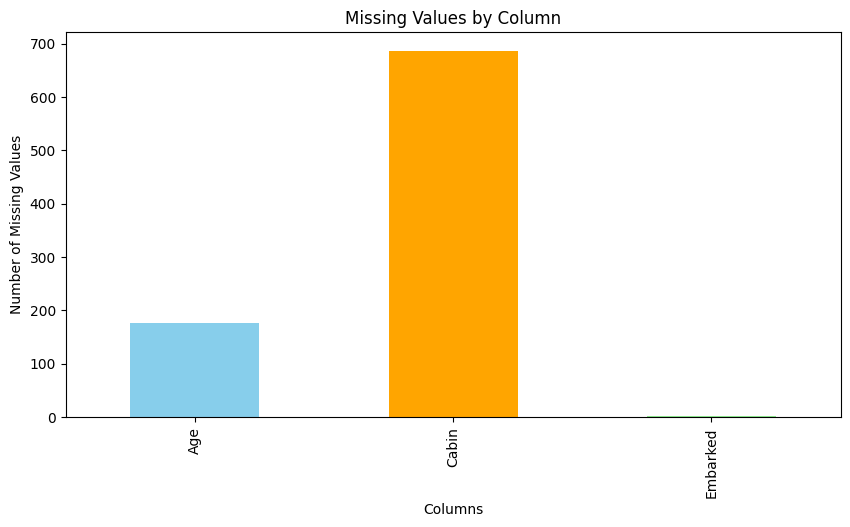

In [13]:
# 12.Create a Bar Chart To Visualize The Missing Values

import matplotlib.pyplot as plt
miss_counts=df.isnull().sum()
miss_counts[miss_counts>0].plot(
    kind='bar',
    figsize=(10,5),
    title='Missing Values by Column',
    color=['skyblue', 'orange', 'lightgreen']
)

plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()



### Observation

The bar chart shows the missing values in each column.
The `Cabin` column has the highest number of missing values,
followed by `Age` and `Embarked`.

## Final Observation

The analysis identified missing values in the `Age`, `Cabin`, and
`Embarked` columns. The `Cabin` column has the highest number of
missing values, followed by `Age` and `Embarked`. The remaining
columns have no missing values.


________________________________________________________________

#Conclusion

Missing values were successfully identified and summarized using
Pandas. The analysis helped understand where missing data occurs
and its extent. No values were removed or changed because the
task focused only on identifying missing values.
